In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Load and do the basic structure check
df = pd.read_csv('../data/Salary_dataset.csv')

## EDA on Salary_dataset.csv

In [36]:
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [37]:
df.drop(["Unnamed: 0"], axis = 1,inplace =True)

In [38]:
df.head()


,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


In [39]:
df.shape

(30, 2)

In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [41]:
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.413333,76004.000000
std,2.837888,27414.429785
min,1.200000,37732.000000
25%,3.300000,56721.750000
50%,4.800000,65238.000000
75%,7.800000,100545.750000
max,10.600000,122392.000000


In [42]:
# Missing values & duplicates
df.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

In [43]:
df.duplicated().sum()

np.int64(0)

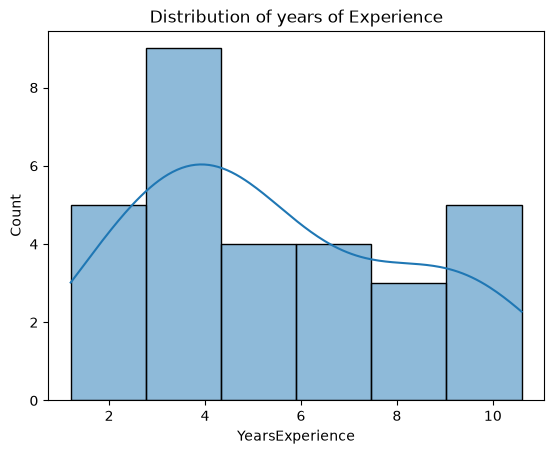

In [44]:
## Univariate Analysis
sns.histplot(df['YearsExperience'],kde=True)
plt.title('Distribution of years of Experience')
plt.show()

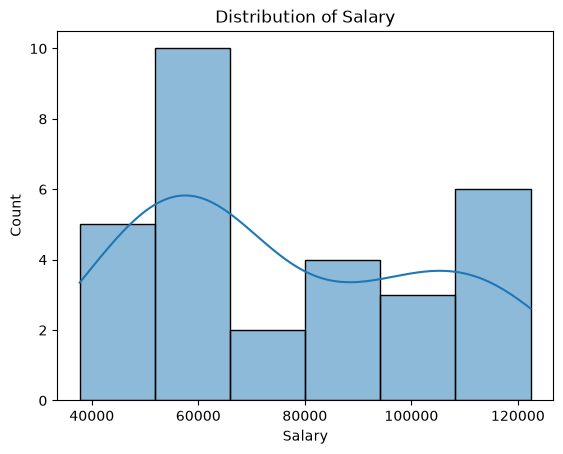

In [45]:
# Salary
sns.histplot(df['Salary'], kde=True)
plt.title('Distribution of Salary')
plt.show()

In [46]:
df[['YearsExperience', 'Salary']].describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.413333,76004.000000
std,2.837888,27414.429785
min,1.200000,37732.000000
25%,3.300000,56721.750000
50%,4.800000,65238.000000
75%,7.800000,100545.750000
max,10.600000,122392.000000


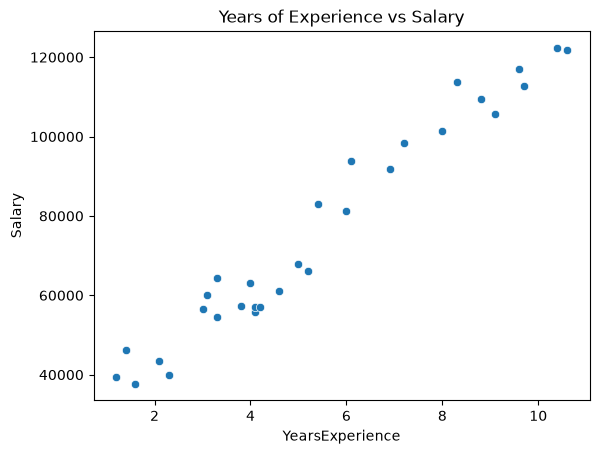

In [47]:
sns.scatterplot(x='YearsExperience', y='Salary',data=df)

plt.title('Years of Experience vs Salary')
plt.show()

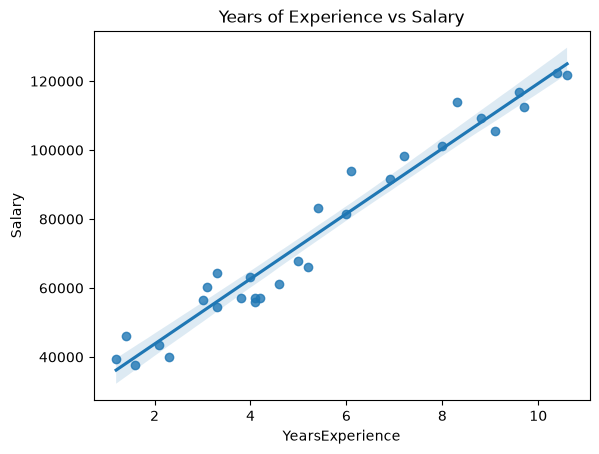

In [48]:
sns.regplot(x='YearsExperience', y='Salary',data=df)
plt.title('Years of Experience vs Salary')
plt.show()

In [49]:
df.corr()

,YearsExperience,Salary
YearsExperience,1.000000,0.978242
Salary,0.978242,1.000000


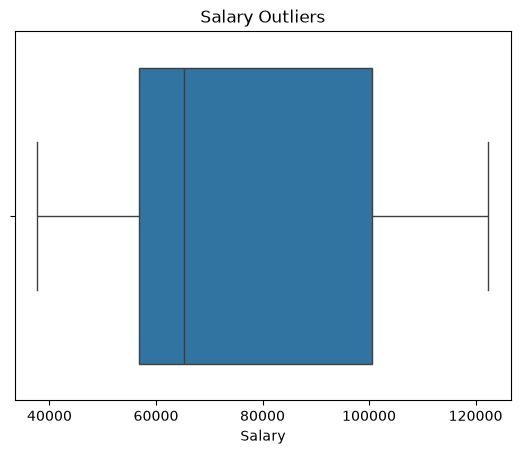

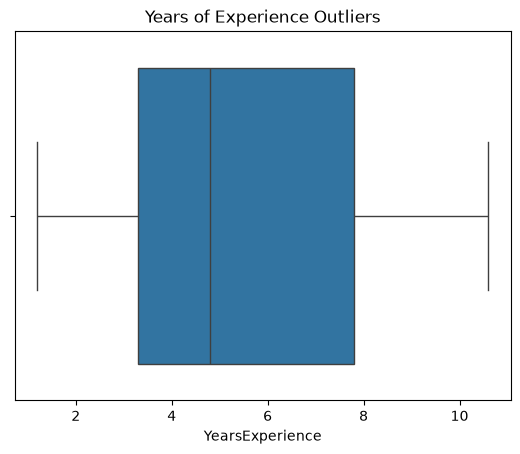

In [50]:
#Outlier Check
sns.boxplot(x=df['Salary'])
plt.title('Salary Outliers')
plt.show()

sns.boxplot(x=df['YearsExperience'])
plt.title('Years of Experience Outliers')
plt.show()

## Phase 3 — Feature Engineering
For Simple Linear Regression, feature engineering is lighter than more complex models, but these steps still matter and set the pattern you'll repeat for every future model.

In [51]:
 #Handle Outliers
Q1 = df['Salary'].quantile(0.25)
Q3 = df['Salary'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['Salary'] >= lower_bound) & (df['Salary'] <= upper_bound)]

In [52]:
#Define Features (X) and Target (y)
X = df[['YearsExperience']]   # double brackets → keeps it as a DataFrame, not Series
y = df['Salary']

In [53]:
#Train-Test Split

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)


In [54]:
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(24, 1) (6, 1) (24,) (6,)


## Modelling (LinearRegression)

In [55]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [56]:
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[9423.82]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['YearsExperience']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.438e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [57]:
print("Slope (Coefficient):", model.coef_)
print("Intercept :", model.intercept_)

Slope (Coefficient): [9423.81532303]
Intercept : 24380.20147947369


In [58]:
y_pred = model.predict(X_test)

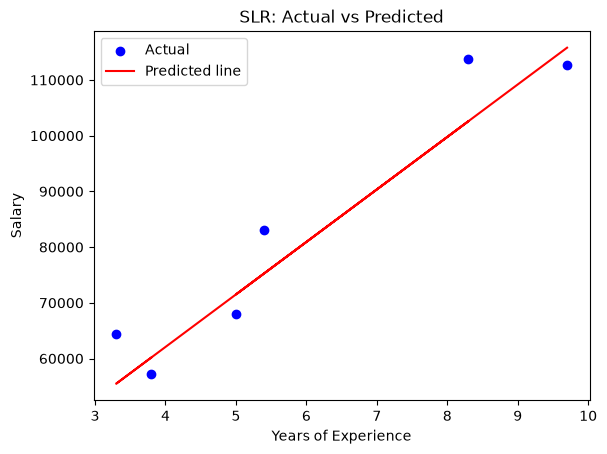

In [59]:
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(X_test, y_pred, color='red', label='Predicted line')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('SLR: Actual vs Predicted')
plt.legend()
plt.show()

In [60]:
#Evaluation Metrics

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import numpy as np

In [61]:
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 6286.453830757745
MSE: 49830096.855908334
RMSE: 7059.043621901506
R² Score: 0.9024461774180498


The model explains 90% of the variance in salary based on years of experience, with an average prediction error of £7059.

In [62]:
#Model Persistence with pickle
import pickle

with open('../src/salary_model.pkl', 'wb') as file:
    pickle.dump(model, file)



In [63]:
with open('../src/salary_model.pkl','rb') as file:
    loaded_model = pickle.load(file)

#test it works identically
test_pred = loaded_model.predict(X_test)
print(test_pred)

[115791.21011287  71499.27809463 102597.86866063  75268.80422384
  55478.79204548  60190.69970699]
